## Classification Exploration 3: Naive Bayes

# [Classification: Naive Bayes](https://en.wikipedia.org/wiki/Naive_Bayes_classifier)

The IBM HR Analytics Employee Attrition dataset contains fictional data created by IBM data scientists. 
It includes 1,470 employee records with 35 features covering demographics, job roles, satisfaction levels, 
and compensation. The target variable is **Attrition** — whether an employee left the company (Yes/No).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Drop constant columns
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'])

# Encode categorical columns
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField',
                                  'Gender', 'JobRole', 'MaritalStatus', 'OverTime'],
                    drop_first=True)

# Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.30,
                                                     stratify=y,
                                                     random_state=123)

print(X_train.shape, X_test.shape)

(1029, 44) (441, 44)


## Naive Bayes Method

In [9]:
'''
NAIVE BAYES classifier:

(1) Training is fast because only the probability of each class and the probability 
    of each class given different input (x) values need to be calculated.
(2) No coefficients need to be fitted by optimization procedures!

BernoulliNB: assumes all features are binary
MultinomialNB: used for discrete data
GaussianNB: extends Naive Bayes to real-valued attributes by assuming a Gaussian distribution
'''

from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

In [10]:
#EVALUATE YOUR PREDICTION
from sklearn.metrics import f1_score

print('***RESULTS ON TRAIN SET***')
print("f1_score: ", f1_score(y_train, y_pred_train))
print('***RESULTS ON TEST SET***')
print("f1_score: ", f1_score(y_test, y_pred))

***RESULTS ON TRAIN SET***
f1_score:  0.4427767354596623
***RESULTS ON TEST SET***
f1_score:  0.43946188340807174


In [11]:
#PRINT SOME FURTHER METRICS
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.72      0.81       370
           1       0.32      0.69      0.44        71

    accuracy                           0.72       441
   macro avg       0.62      0.71      0.62       441
weighted avg       0.83      0.72      0.75       441



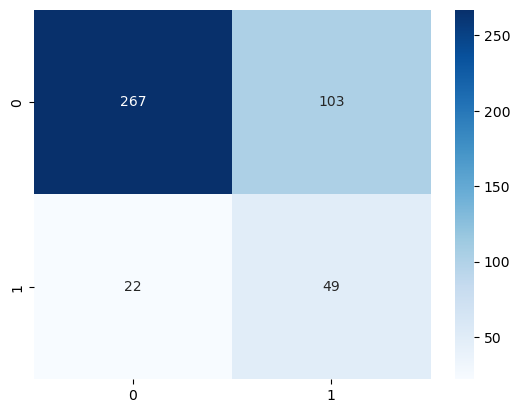

In [13]:
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.show()

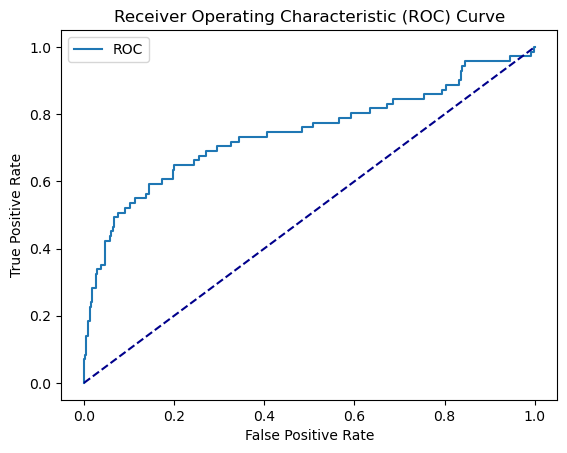

AUC: 0.74


In [14]:
from sklearn import metrics

y_probs = model.predict_proba(X_test)

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_probs[:, 1])

plt.plot(fpr, tpr, label='ROC')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

auc = metrics.roc_auc_score(y_test, y_probs[:, 1])
print('AUC: %.2f' % auc)

## Apply PCA

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA — reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Convert to DataFrame
X_pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
X_pca_df["Target"] = y.values

X_pca_df.head()

,PC1,PC2,Target
0,-0.034512,2.271801,1
1,0.097444,-1.569353,0
2,-2.871946,-0.993176,1
3,-1.222608,-1.126880,0
4,-2.075628,-1.211932,0


In [16]:
# Train Gaussian Naive Bayes on the PCA-transformed data
gnb = GaussianNB()
gnb.fit(X_pca, y)

y_pred = gnb.predict(X_pca)

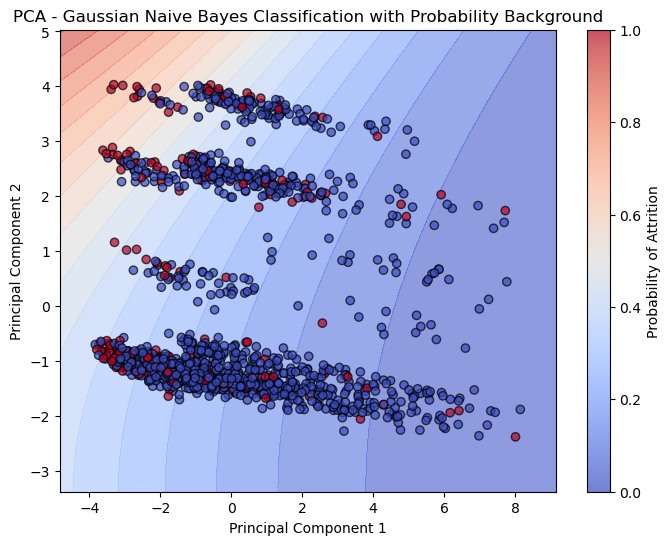

In [17]:
import numpy as np

# Create a mesh grid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Compute probability of class 1 for each grid point
Z = gnb.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Plot the probability contour
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.6)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", edgecolors="k", alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Gaussian Naive Bayes Classification with Probability Background")
plt.colorbar(label="Probability of Attrition")
plt.show()

## Summary

In this notebook we applied a Gaussian Naive Bayes classifier to predict employee attrition using the IBM HR dataset.

Naive Bayes delivered the best AUC so far while being the simplest and fastest model:

- **F1 train = 0.44, F1 test = 0.44** — virtually no overfitting, the model generalizes well by design
- **AUC = 0.74** — best across all three notebooks so far

Compared to previous notebooks:

| Model | F1 Test | AUC |
|-------|---------|-----|
| KNN | 0.22 | 0.54 |
| Decision Tree | 0.44 | 0.69 |
| Naive Bayes | 0.44 | 0.74 |

Key takeaways:
- **No overfitting**: Naive Bayes makes strong independence assumptions that act as a natural regularizer
- **Fast training**: no optimization procedure needed, only probabilities are estimated
- **PCA visualization**: reducing to 2 components reveals three horizontal clusters in the data, likely driven by department or job level, with attrition cases concentrated on the left side of the feature space

The independence assumption of Naive Bayes is a limitation — in reality, features like MonthlyIncome and JobLevel are correlated. Ensemble methods in the next notebooks should be able to capture these interactions and push performance further.